# Assignment 7: Gradient Descent from Scratch


### Objective
To understand how Gradient Descent learns the parameters of a simple linear model by repeatedly reducing prediction error.

## Overview

Gradient Descent is an optimization technique used to improve model parameters during training. Instead of selecting the best parameters directly, the algorithm starts with initial values and gradually adjusts them according to the direction of the error.

In this experiment, a linear relationship is learned using a small numerical dataset. Mean Squared Error (MSE) is used to monitor how well the model is fitting the data.

## How the Algorithm Works

The experiment follows this cycle:

1. Start with initial values for the model parameters.
2. Generate predictions from the current model.
3. Measure the prediction error using MSE.
4. Find the gradients of the loss with respect to the parameters.
5. Move the parameters in the direction that reduces the loss.
6. Repeat the process until the model approaches a suitable solution.

## Model and Update Rule

We use a straight-line model:

**prediction = weight × input + bias**

For this experiment, MSE is used as the error measure. The parameter changes are based on the gradients of this error. The learning rate determines the size of each adjustment.

A smaller loss means that the generated values are closer to the target values.

## Task 1: Build a Small Dataset

The following values follow the pattern **y = 3x + 1**. Using a simple relationship makes it easier to observe how the parameters move toward the underlying pattern.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Input and target values
inputs = np.array([1, 2, 3, 4, 5, 6, 7, 8], dtype=float)
targets = np.array([4, 7, 10, 13, 16, 19, 22, 25], dtype=float)

print("Inputs:", inputs)
print("Target values:", targets)

Inputs: [1. 2. 3. 4. 5. 6. 7. 8.]
Target values: [ 4.  7. 10. 13. 16. 19. 22. 25.]


## Inspecting the Data

A scatter plot gives a quick view of the relationship between the input and target variables.

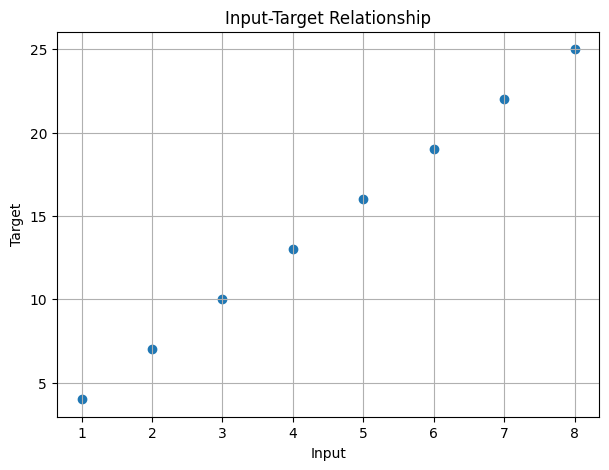

In [2]:
plt.figure(figsize=(7, 5))
plt.scatter(inputs, targets)
plt.xlabel("Input")
plt.ylabel("Target")
plt.title("Input-Target Relationship")
plt.grid(True)
plt.show()

## Task 2: Set Initial Parameters

The model begins without any learned relationship. Both parameters are initialized to zero. A learning rate of 0.01 is used and the training loop runs for 1200 iterations.

In [3]:
weight = 0.0
bias = 0.0
step_size = 0.01
epochs = 1200

print("Starting weight:", weight)
print("Starting bias:", bias)
print("Learning rate:", step_size)
print("Training iterations:", epochs)

Starting weight: 0.0
Starting bias: 0.0
Learning rate: 0.01
Training iterations: 1200


## First Prediction

Before training, the model uses its initial weight and bias to generate values. Since both are zero, the first set of predictions does not capture the pattern in the data.

In [4]:
first_prediction = weight * inputs + bias

print("Predictions before training:")
print(first_prediction)

Predictions before training:
[0. 0. 0. 0. 0. 0. 0. 0.]


## Measuring Prediction Error

MSE is used to summarize the difference between the target values and the model's predictions. Squaring the differences prevents positive and negative errors from cancelling each other.

In [5]:
def mse(actual, predicted):
    error = actual - predicted
    return np.mean(error ** 2)

starting_loss = mse(targets, first_prediction)
print("MSE before training:", starting_loss)

MSE before training: 257.5


## Task 3: Train with Gradient Descent

At every iteration, the model calculates its current predictions and error, obtains the gradients, and then updates the weight and bias. Loss and parameter values are saved so their progress can be examined later.

In [6]:
# Reset parameters for the training run
weight = 0.0
bias = 0.0

loss_values = []
weight_values = []
bias_values = []

for epoch in range(epochs):
    predictions = weight * inputs + bias

    current_loss = mse(targets, predictions)
    loss_values.append(current_loss)
    weight_values.append(weight)
    bias_values.append(bias)

    # Gradients of MSE
    grad_weight = (-2 / len(inputs)) * np.sum(inputs * (targets - predictions))
    grad_bias = (-2 / len(inputs)) * np.sum(targets - predictions)

    # Move parameters using the gradients
    weight -= step_size * grad_weight
    bias -= step_size * grad_bias

print("Learned weight:", weight)
print("Learned bias:", bias)
print("Final MSE:", loss_values[-1])

Learned weight: 3.000661521328762
Learned bias: 0.9962807237621325
Final MSE: 2.8715401929124727e-06


## Tracking Parameter Changes

The selected checkpoints below show how the model parameters change from their starting values toward values that describe the dataset.

In [7]:
checkpoints = [0, 1, 9, 49, 199, 599, 1199]

print("Iteration\tWeight\t\tBias\t\tMSE")
print("-" * 55)

for index in checkpoints:
    print(f"{index + 1}\t\t{weight_values[index]:.4f}\t\t{bias_values[index]:.4f}\t\t{loss_values[index]:.4f}")

Iteration	Weight		Bias		MSE
-------------------------------------------------------
1		0.0000		0.0000		257.5000
2		1.6200		0.2900		57.8845
10		3.0738		0.5632		0.0395
50		3.0661		0.6284		0.0284
200		3.0363		0.7961		0.0086
600		3.0073		0.9588		0.0003
1200		3.0007		0.9963		0.0000


## Observing the Loss Curve

A successful training run should show the error moving downward as the model parameters improve.

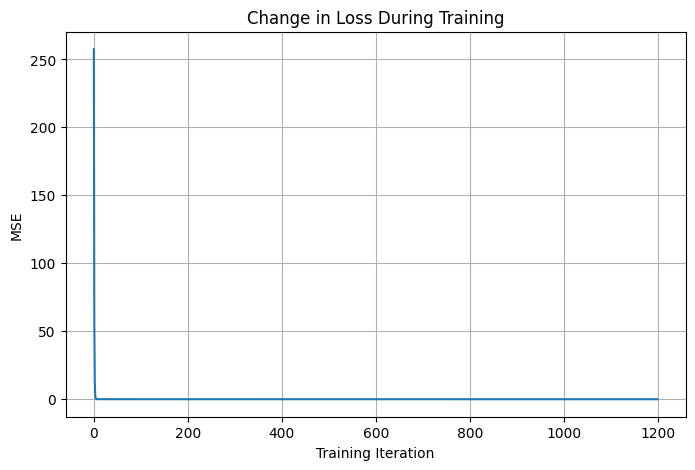

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(loss_values)
plt.xlabel("Training Iteration")
plt.ylabel("MSE")
plt.title("Change in Loss During Training")
plt.grid(True)
plt.show()

## Generate Predictions After Training

Once the optimization is complete, the learned weight and bias are used to calculate the final predictions.

In [9]:
trained_predictions = weight * inputs + bias

print("Input\tTarget\tPrediction")
print("-" * 32)

for i in range(len(inputs)):
    print(f"{inputs[i]:.0f}\t{targets[i]:.0f}\t{trained_predictions[i]:.2f}")

Input	Target	Prediction
--------------------------------
1	4	4.00
2	7	7.00
3	10	10.00
4	13	13.00
5	16	16.00
6	19	19.00
7	22	22.00
8	25	25.00


## Actual and Model Output

The next plot places the original observations and the fitted line together. A close match indicates that the learned parameters capture the pattern in the dataset.

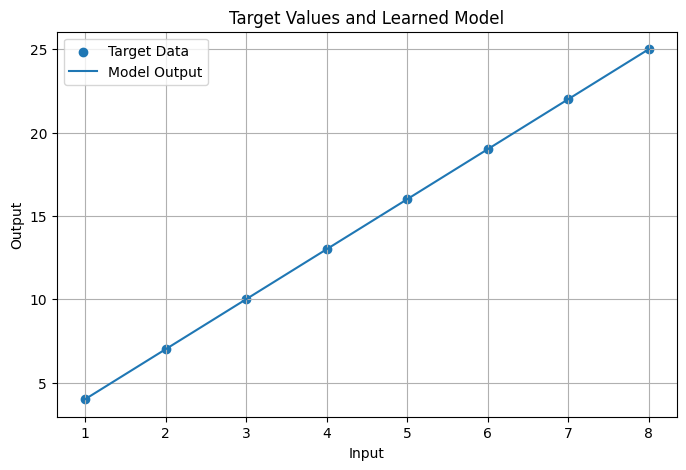

In [10]:
plt.figure(figsize=(8, 5))
plt.scatter(inputs, targets, label="Target Data")
plt.plot(inputs, trained_predictions, label="Model Output")
plt.xlabel("Input")
plt.ylabel("Output")
plt.title("Target Values and Learned Model")
plt.legend()
plt.grid(True)
plt.show()

## Results

The model began with a weight and bias of 0, producing an initial MSE of **257.5**. After 1200 Gradient Descent iterations, the learned weight is approximately **3.0007** and the bias is approximately **0.9963**.

The final MSE is approximately **0.0000029**, which is much smaller than the starting error. The predictions are therefore very close to the target values generated by the relationship y = 3x + 1.

## Analysis

The experiment shows that Gradient Descent can learn a simple linear relationship without directly giving the algorithm the correct weight and bias. The model started from zero parameters, so its initial predictions were far from the target values.

With every iteration, the gradients indicated how the parameters should be adjusted to reduce the MSE. The stored loss values show that the error decreased substantially during training. At the end of the process, the weight and bias were very close to 3 and 1, which are the parameters of the pattern used to create the dataset.

The result demonstrates the basic optimization idea used in machine learning: parameters are repeatedly adjusted based on the loss until the model produces much smaller prediction errors.

## Conclusion

In this project, Gradient Descent was implemented using Python for a simple linear prediction problem. A dataset following a known linear pattern was created, and the model initially started with zero-valued parameters.

Mean Squared Error was used to monitor the model's performance while the weight and bias were updated through repeated gradient calculations. The loss curve decreased during training, and the final predictions closely matched the target values.

Thus, the experiment provides a practical demonstration of how Gradient Descent adjusts model parameters to reduce prediction error and improve the fit of a machine learning model.